#Predicción de consumo de energía eléctrica de una planta de envases de aluminio ubicada en la ciudad de Guarambaré.
### Alumno: Diego R. Valenzuela Bernal.
#### Objetivo: Crear un modelo capaz de predecir el consumo eléctrico a partir de variables de producción y variables meteorológicas para dar soporte a la planificación energética y para detectar de manera rápida anomalías asociadas al consumo energético.
#### Hipótesis: El consumo de energía de la planta depende de la producción del producto A, producción del producto B, las variables meteorológicas, el día de la semana y si el día fue festivo o no (feriados).

In [1]:
#Libreria necesaria para exportar los días que son feriados en Paraguay
!pip install holidays -q

#Importamos las librerias necesarias.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import requests

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)

### Cargamos el archivo base (proveido por la empresa localizada en Guarambare)

In [2]:
df_2024 = pd.read_excel("Total Released TA 2022 a 2026.xlsx")
print(df_2024.columns.tolist())
print(df_2024.head())
print(df_2024.dtypes)

['Date', 'Consumo', 'Total Released TA', 'TBCS']
        Date  Consumo  Total Released TA  TBCS
0 2021-10-01  22612.0            12171.6   NaN
1 2021-10-02  23235.0            11970.0   NaN
2 2021-10-03  22839.0            11592.0   NaN
3 2021-10-04  23329.0            12461.4   NaN
4 2021-10-05  24390.0            11495.4   NaN
Date                 datetime64[ns]
Consumo                     float64
Total Released TA           float64
TBCS                        float64
dtype: object


### Empezamos a agregar variables utililes para el análisis:


1.   Día de la semana.
2.   El día es parte del fin de semana.
3.   Holidays (feriados en Paraguay).
4.   Temperatura máxima, mínima y promedio de la zona más cercana.
5.   Humedad de la zona más cercana.



In [3]:
#Obtenemos temperatura y humedad de Guarambaré utilizando Open Meteo

#Las coordenadas aproximadas de Guarambaré
lat, lon = -25.42, -57.44

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2021-01-01",
    "end_date": "2026-10-04",  # ajustá a tu fecha más reciente de datos
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "relative_humidity_2m_mean"
    ],
    "timezone": "America/Asuncion"
}

response = requests.get(url, params=params)
data = response.json()

df_clima = pd.DataFrame({
    "Date": pd.to_datetime(data["daily"]["time"]),
    "temp_max": data["daily"]["temperature_2m_max"],
    "temp_min": data["daily"]["temperature_2m_min"],
    "temp_prom": data["daily"]["temperature_2m_mean"],
    "humedad": data["daily"]["relative_humidity_2m_mean"]
})

df_clima.head()

,Date,temp_max,temp_min,temp_prom,humedad
0,2021-01-01,30.2,19.3,24.8,64
1,2021-01-02,32.9,20.0,26.6,60
2,2021-01-03,33.7,22.1,27.9,56
3,2021-01-04,31.7,23.9,27.0,71
4,2021-01-05,28.6,22.9,25.3,85


In [4]:
#Agregamos el día de la semana correspondiente a la fecha
df_2024['dia_semana'] = df_2024['Date'].dt.day_name() #Nos da el día en inglés

#Agregamos si el día fue o no parte de un Fin de semana
df_2024['es_fin_de_semana'] = df_2024['dia_semana'].isin(['Saturday', 'Sunday']).astype(int)

#Agregamos si fue feriado
feriados_py = holidays.Paraguay(years=range(2021, 2027))
df_2024['es_feriado'] = df_2024['Date'].isin(feriados_py).astype(int)

# Para revisar qué feriados detectó:
#for fecha, nombre in sorted(feriados_py.items()):
#    print(fecha, nombre)

/tmp/ipykernel_20043/435027040.py:9: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_2024['es_feriado'] = df_2024['Date'].isin(feriados_py).astype(int)


In [5]:
#Ya tenemos nuestro DF con todos los datos necesarios para el análisis.
df_final = df_2024.merge(df_clima, on="Date", how="left")

df_final.head()

,Date,Consumo,Total Released TA,TBCS,dia_semana,es_fin_de_semana,es_feriado,temp_max,temp_min,temp_prom,humedad
0,2021-10-01,22612.0,12171.6,NaN,Friday,0,0,26.9,20.7,24.0,80
1,2021-10-02,23235.0,11970.0,NaN,Saturday,1,0,28.0,20.0,23.2,85
2,2021-10-03,22839.0,11592.0,NaN,Sunday,1,0,23.3,20.0,21.9,87
3,2021-10-04,23329.0,12461.4,NaN,Monday,0,0,19.5,14.7,17.1,74
4,2021-10-05,24390.0,11495.4,NaN,Tuesday,0,0,25.9,14.7,20.1,72


### Una vez concluido la construcción del dataset, verificamos el estado del mismo.

In [6]:
# Resumen general de nulos por columna
print(df_final.isna().sum())
print()
print((df_final.isna().sum() / len(df_final) * 100).round(2))
#El 5% de nuestros datos poseen NA en la columna TBCS (producto 2)

Date                  0
Consumo               0
Total Released TA     0
TBCS                 92
dia_semana            0
es_fin_de_semana      0
es_feriado            0
temp_max              0
temp_min              0
temp_prom             0
humedad               0
dtype: int64

Date                 0.00
Consumo              0.00
Total Released TA    0.00
TBCS                 5.08
dia_semana           0.00
es_fin_de_semana     0.00
es_feriado           0.00
temp_max             0.00
temp_min             0.00
temp_prom            0.00
humedad              0.00
dtype: float64


In [7]:
# Verificamos que no falten fechas (continuidad de la serie)
rango_completo = pd.date_range(df_final['Date'].min(), df_final['Date'].max())
faltantes = rango_completo.difference(df_final['Date'])
print(f'{len(faltantes)} fechas faltantes')
if len(faltantes) > 0:
    print(faltantes)

0 fechas faltantes


### Tenemos la siguiente situación con los datos obtenidos de la producción.

*   Año 2021: Poseemos datos diarios del producto A (TA). No poseemos datos del producto B (TBCS).
*   Año 2022 y 2023: Poseemos datos diarios del producto A (TA). Poseemos datos mensuales del producto B (TBCS) - Se procede a diluir la producción mensual diviendo por la cantidad de días.
*   Año 2024 al Año 2026: Poseemos datos diarios del producto A (TA). Poseemos datos diarios del producto B (TBCS).


Obs: usaremos estos periodos para filtrar los días.


In [8]:
# TBCS por año — para confirmar el patrón mensual 2021-2023 vs diario 2024+
df_final['anio'] = df_final['Date'].dt.year
#print(df_final.groupby('anio')['TBCS'].apply(lambda x: x.notna().sum()))

condiciones = [
    df_final['anio'] == 2021,
    df_final['anio'].between(2022, 2023),
    df_final['anio'] >= 2024
]
valores = ['sin_B', 'B_diluido', 'B_real']

df_final['periodo'] = np.select(condiciones, valores, default='sin_definir')

df_final['periodo'].value_counts()

df_final.head()

,Date,Consumo,Total Released TA,TBCS,dia_semana,es_fin_de_semana,es_feriado,temp_max,temp_min,temp_prom,humedad,anio,periodo
0,2021-10-01,22612.0,12171.6,NaN,Friday,0,0,26.9,20.7,24.0,80,2021,sin_B
1,2021-10-02,23235.0,11970.0,NaN,Saturday,1,0,28.0,20.0,23.2,85,2021,sin_B
2,2021-10-03,22839.0,11592.0,NaN,Sunday,1,0,23.3,20.0,21.9,87,2021,sin_B
3,2021-10-04,23329.0,12461.4,NaN,Monday,0,0,19.5,14.7,17.1,74,2021,sin_B
4,2021-10-05,24390.0,11495.4,NaN,Tuesday,0,0,25.9,14.7,20.1,72,2021,sin_B


### Serie temporal del consumo completo.

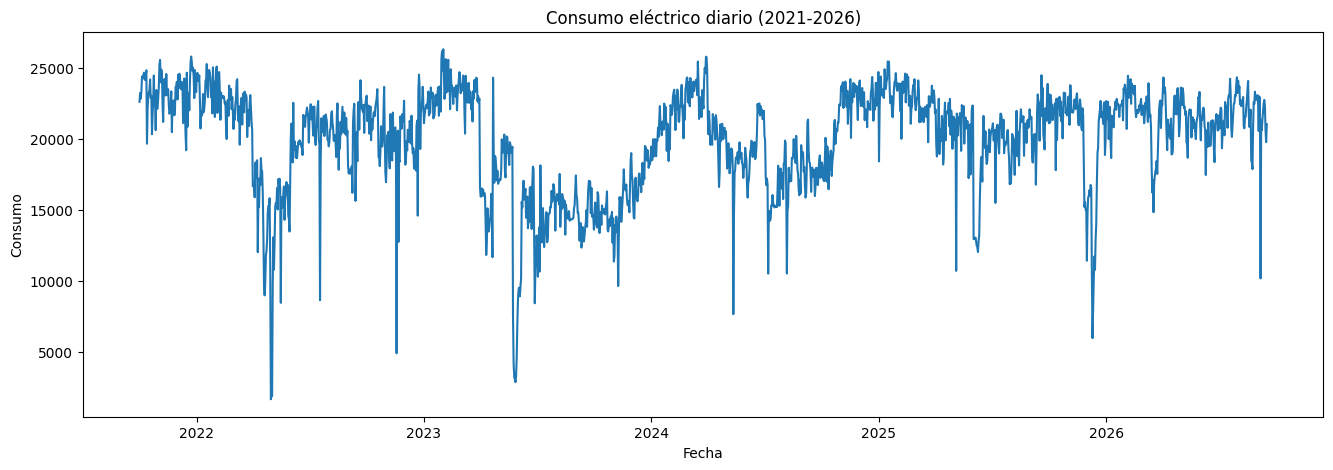

In [9]:
plt.figure(figsize=(16,5))
plt.plot(df_final['Date'], df_final['Consumo'])
plt.title('Consumo eléctrico diario (2021-2026)')
plt.xlabel('Fecha')
plt.ylabel('Consumo')
plt.show()

### Distribución del consumo.

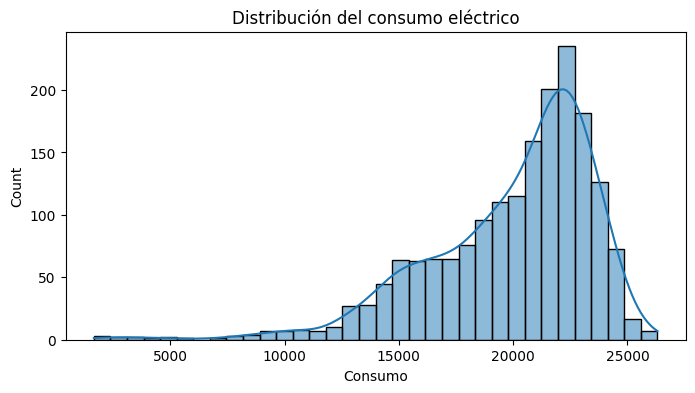

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df_final['Consumo'], kde=True)
plt.title('Distribución del consumo eléctrico')
plt.show()

### Correlación entre variables numéricas.

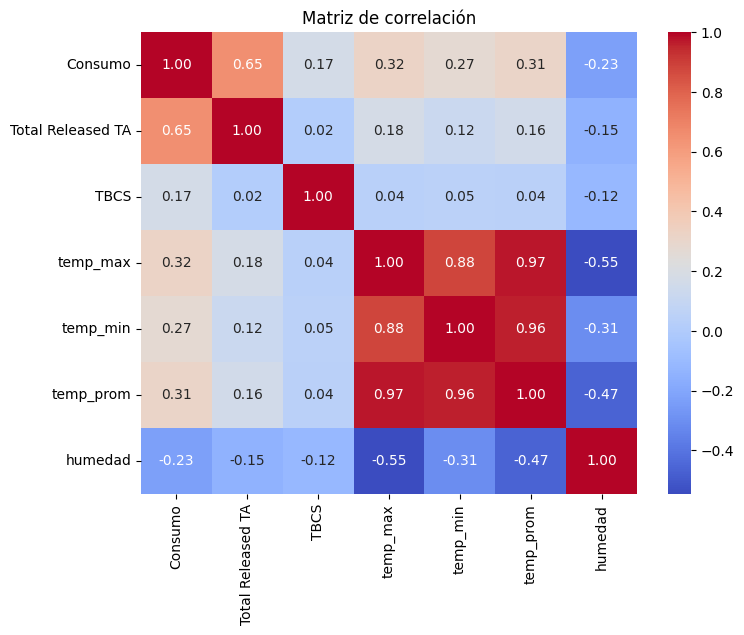

In [11]:
num_cols = ['Consumo', 'Total Released TA', 'TBCS', 'temp_max', 'temp_min', 'temp_prom', 'humedad']
corr = df_final[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

### Consumo según día/es feriado o no.

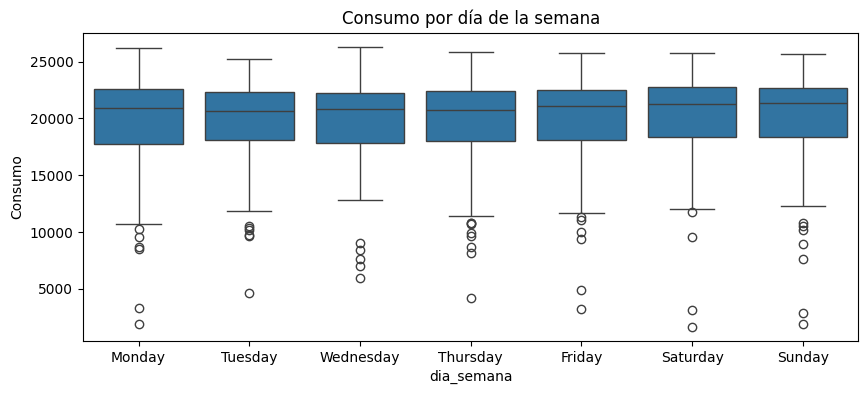

In [12]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df_final, x='dia_semana', y='Consumo',
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Consumo por día de la semana')
plt.show()

### Consumo vs producción, por scatter

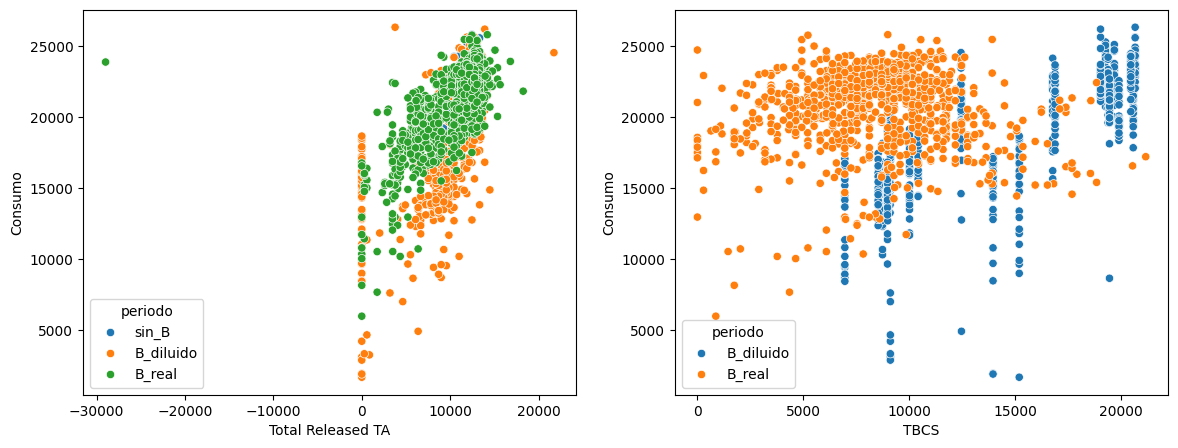

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=df_final, x='Total Released TA', y='Consumo', hue='periodo', ax=axes[0])
sns.scatterplot(data=df_final[df_final['periodo']!='sin_B'], x='TBCS', y='Consumo', hue='periodo', ax=axes[1])
plt.show()

### Observamos que hay outliers en Total Released TA (producto A)

In [14]:
df_final[df_final['Total Released TA'] < 0]

#Como no puede existir una producción negativa, cambiamos el valor negativo por un NaN

df_final.loc[df_final['Total Released TA'] < 0, 'Total Released TA'] = np.nan

# Confirmamos que ya no queda ningún negativo
#print((df_final['Total Released TA'] < 0).sum())
#print(df_final['Total Released TA'].isna().sum())

### Después de ver el gráfico de scatter y el de correlación, vamos a tomar dos escenarios diferentes respecto a los datos y a su ánalisis:


1.   #### Escenario 1: Total Released TA (producto A) + variables meteorológicas utilizando datos de 2021 al 2026.
2.   #### Escenario 2: Total Released TA (producto A) + TBCS (producto B) reales + variables meteorológicas utilizando datos desde el 2024 al 2026.



In [15]:
# Escenario 1
df_esc1 = df_final[df_final['Total Released TA'].notna()].copy()

# Escenario 2 — solo período con TBCS real
df_esc2 = df_final[df_final['periodo'] == 'B_real'].copy()

print(f'Escenario 1: {len(df_esc1)} filas')
print(f'Escenario 2: {len(df_esc2)} filas')

Escenario 1: 1811 filas
Escenario 2: 990 filas


## Empezamos a construir el módelo de ML

1.  ### Realizamos el split del train/test para cada escenario.

In [16]:
from sklearn.model_selection import train_test_split

# --- Escenario 1: solo A + meteorología (2021-2026) ---
features_esc1 = ['Total Released TA', 'temp_max', 'temp_min', 'temp_prom', 'humedad',
                  'dia_semana', 'es_feriado', 'es_fin_de_semana']
target = 'Consumo'

# sacamos la fila del negativo convertido a NaN
df_esc1_clean = df_esc1.dropna(subset=['Total Released TA'])

X1 = df_esc1_clean[features_esc1]
y1 = df_esc1_clean[target]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, shuffle=False)

# --- Escenario 2: A + B reales + meteorología (2024-2026) ---
features_esc2 = ['Total Released TA', 'TBCS', 'temp_max', 'temp_min', 'temp_prom', 'humedad',
                  'dia_semana', 'es_feriado', 'es_fin_de_semana']

X2 = df_esc2[features_esc2]
y2 = df_esc2[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, shuffle=False)

print(f'Escenario 1 → train: {len(X1_train)}, test: {len(X1_test)}')
print(f'Escenario 2 → train: {len(X2_train)}, test: {len(X2_test)}')

Escenario 1 → train: 1448, test: 363
Escenario 2 → train: 792, test: 198


2. ### ColumnTransformer + Pipeline para cada uno

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

# --- Pipeline Escenario 1 ---
num_cols_1 = ['Total Released TA', 'temp_max', 'temp_min', 'temp_prom', 'humedad']
cat_cols_1 = ['dia_semana', 'es_feriado', 'es_fin_de_semana']

preprocesador_1 = ColumnTransformer([
    ('num', StandardScaler(), num_cols_1),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_cols_1)
])

pipeline_esc1 = Pipeline([
    ('preprocesamiento', preprocesador_1),
    ('modelo', RandomForestRegressor(n_estimators=200, random_state=42))
])

# --- Pipeline Escenario 2 ---
num_cols_2 = ['Total Released TA', 'TBCS', 'temp_max', 'temp_min', 'temp_prom', 'humedad']
cat_cols_2 = ['dia_semana', 'es_feriado', 'es_fin_de_semana']

preprocesador_2 = ColumnTransformer([
    ('num', StandardScaler(), num_cols_2),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_cols_2)
])

pipeline_esc2 = Pipeline([
    ('preprocesamiento', preprocesador_2),
    ('modelo', RandomForestRegressor(n_estimators=200, random_state=42))
])

3. ### Entrenar ambos

In [ ]:
pipeline_esc1.fit(X1_train, y1_train)
pipeline_esc2.fit(X2_train, y2_train)

4. ### Evaluar ambos lado a lado

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluar(pipeline, X_test, y_test, nombre):
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    print(f'--- {nombre} ---')
    print(f'MAE (Error absoluto medio):  {mae:.2f} kWh')
    print(f'RMSE (Raiz del error cuadrático medio): {rmse:.2f} kWh')
    print(f'MAPE (Error porcentual): {mape:.2f}%\n')
    return y_pred

y1_pred = evaluar(pipeline_esc1, X1_test, y1_test, 'Escenario 1 (solo A)')
y2_pred = evaluar(pipeline_esc2, X2_test, y2_test, 'Escenario 2 (A+B real)')

#### Conclusión de la comparación: Podemos decir que el Escenario 2 es mejor. Solo hay un pequeño detalle a considerar: el escenario 1 usa datos desde 2021 hasta 2026, el escenario 2 usa datos desde el 2024 hasta el 2026.

#### Vamos a utilizar el mismo rango de tiempo para ambos (2024 a 2026) modelos y volvemos a comparar a ver los resultados de las pruebas.

In [ ]:
# Tomar del Escenario 1 solo las filas que caen en el rango de fechas del test del Escenario 2
fecha_inicio_test2 = df_esc2.loc[X2_test.index, 'Date'].min()

X1_test_mismo_periodo = df_esc1_clean[df_esc1_clean['Date'] >= fecha_inicio_test2][features_esc1]
y1_test_mismo_periodo = df_esc1_clean[df_esc1_clean['Date'] >= fecha_inicio_test2][target]

evaluar(pipeline_esc1, X1_test_mismo_periodo, y1_test_mismo_periodo, 'Escenario 1 (mismo período que Esc. 2)')

#### El MAPE del Escenario 1 sigue siendo significativamente mayor que el 3.77% del Escenario 2 incluso en el mismo periodo.

### Verificamos la importancia de nuestras variables: mostramo que tan determinantes fue TBCS frente a las otras variables.

In [ ]:
importancias = pipeline_esc2.named_steps['modelo'].feature_importances_
nombres_cols = pipeline_esc2.named_steps['preprocesamiento'].get_feature_names_out()

import pandas as pd
df_importancia = pd.DataFrame({'variable': nombres_cols, 'importancia': importancias})
df_importancia = df_importancia.sort_values('importancia', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=df_importancia, x='importancia', y='variable')
plt.title('Importancia de variables - Escenario 2')
plt.show()

Confirmamos exactamente lo que esperábamos:

*   Total Released TA domina con ~65% de la importancia — es la
variable que más explica el consumo, lo cual tiene sentido físico (a mayor producción, mayor consumo eléctrico de máquinas/línea).
*   TBCS aporta un ~17% adicional — es justo esa porción de información que el Escenario 1 no tenía, y explica por qué el error cae a la mitad al incluirla.
*   Las variables climáticas (temp_prom, temp_max, temp_min, humedad) suman entre todas apenas un ~15-18%, con temp_prom como la más relevante del grupo — tiene sentido, ya que afecta cosas como climatización o eficiencia de ciertos equipos, pero es un efecto secundario frente a la producción.
*   Día de la semana y feriados son prácticamente irrelevantes (barras casi en cero) — esto confirma lo que ya sabías del negocio: la planta produce todos los días sin pausas por fin de semana o feriado, así que esas variables no aportan señal real.


# Guardamos el modelo entrenado

In [ ]:
import joblib

joblib.dump(pipeline_esc2, 'modelo_consumo_escenario2.pkl')

Cargamos nuevamente el modelo

In [ ]:
modelo_cargado = joblib.load('modelo_consumo_escenario2.pkl')

Hacer inferencia sobre un caso nuevo

In [ ]:
import pandas as pd

dato_nuevo = pd.DataFrame({
    'Total Released TA': [12500],
    'TBCS': [8000],
    'temp_max': [30.5],
    'temp_min': [21.0],
    'temp_prom': [25.8],
    'humedad': [78],
    'dia_semana': ['Monday'],
    'es_feriado': [0],
    'es_fin_de_semana': [0]
})

prediccion = modelo_cargado.predict(dato_nuevo)
print(f'Consumo eléctrico predicho: {prediccion[0]:.2f} kWh')

O usamos una fila real para el test

In [ ]:
idx = 0  # elegí cualquier índice del test
fila_real = X2_test.iloc[[idx]]
valor_real = y2_test.iloc[idx]

prediccion = modelo_cargado.predict(fila_real)[0]

print(f'Predicción: {prediccion:.2f} kWh')
print(f'Valor real: {valor_real:.2f} kWh')
print(f'Diferencia: {abs(prediccion - valor_real):.2f} kWh ({abs(prediccion-valor_real)/valor_real*100:.2f}%)')

In [ ]:
# Tomamos una muestra representativa del dataset final (Escenario 2) para crear datos de muestra
df_esc2.sample(n=100, random_state=42).to_csv('datos_muestra.csv', index=False)